# DS 3000 HW 2

Due: Monday June 2 @ 11:59 PM EST

### Submission Instructions
Submit this `ipynb` file to Gradescope (no need to do it through GitHub).  To ensure that your submitted `ipynb` file represents your latest code, make sure to give a fresh `Kernel > Restart & Run All` just before uploading the `ipynb` file to gradescope.

### Tips for success
- Start early
- Make use of Slack
- Remember to use cells, headings and markdown to make the notebook easy to read (if I can't find the answer to a problem, you will receive no points for it)
- Collaborate: bounce ideas off of each other, if you are having trouble you can ask your classmates or Dr. Gerber for help with specific issues, however...
- [(See)](http://www.northeastern.edu/osccr/academic-integrity), i.e. you are welcome to **talk about/discuss** (*not* show or allow each other to copy your answers to) the problems.

### Prize for 3.1

Whoever builds the best model (evaluated in terms of both cross validated $R^2$ and meeting assumptions) will receive a prize of a Belgian soccer flag and a Belgian waffle.

In [3]:
# functions for you
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Part 1: Writing Your Own Linear Regression Functions

In this part, you will write your own linear regression functions that can (and will) be used for both Part 2 and Part 3. You must make sure that your functions pass the assert statements in each sub-part.

## Part 1.1: Line of Best Fit Function (20 points)

Write the function `line_of_best_fit`, including well written docstring, which takes as arguments `X` (an array, either 1-d or 2-d which includes all the predictor values, not including bias term) and `y` (a 1-d array which includes all corresponding response values to `X`) and returns the vector containing the coefficients for the line of best fit, including an intercept term. I have written the `add_bias_column` function below which you will want to use within your `line_of_best_fit` function. **Make sure the assert statement written in the final code cell of this sub-part passes.**

In [6]:
def add_bias_column(X):
    """
    Args:
        X (array): can be either 1-d or 2-d
    
    Returns:
        Xnew (array): the same array, but 2-d with a column of 1's in the first spot
    """
    
    # If the array is 1-d
    if len(X.shape) == 1:
        Xnew = np.column_stack([np.ones(X.shape[0]), X])
    
    # If the array is 2-d
    elif len(X.shape) == 2:
        bias_col = np.ones((X.shape[0], 1))
        Xnew = np.hstack([bias_col, X])
        
    else:
        raise ValueError("Input array must be either 1-d or 2-d")

    return Xnew

In [7]:
def line_of_best_fit(X, y):
    """
    Args:
        X (array): 1-d or 2-d array which includes all the predictor values, not including bias term
        y (array): 1-d array which includes all corresponding response values to X
    
    Returns:
        coeffs (array): coefficients for line of best fit, including intercept term
    """

    X_bias = add_bias_column(X)
    
    XtXinv = np.linalg.inv(np.dot(X_bias.T, X_bias))
    coeffs = np.dot(XtXinv, np.dot(X_bias.T, y))

    return coeffs

In [8]:
X = np.array([0,2,1,0,4])
y = np.array([3,8,2,3,6])

assert (np.isclose(line_of_best_fit(X, y), np.array([3., 1.]))).all()

## Part 1.2: Prediction and Assessment Function (20 points)

Write the function `linreg_predict`, including well written docstring, which takes as arguments:

- `Xnew` (an array, either 1-d or 2-d which includes all the $p$ predictor features, not including bias term)
- `ynew` (a 1-d array which includes all corresponding response values to `Xnew`)
- `b` (a 1-d array of length $p+1$ which contains the coefficients from the `line_of_best_fit` function)

The function should return a dictionary containing four key-value pairs:

- `'ypreds'` (the predicted values from applying `m` to `Xnew`)
- `'resids'` (the residuals, the differences between `ynew` and `ypreds`)
- `'mse'` (the mean squared error)
- `'r2'` (the coefficient of determination ($R^2$) representing the proportion of variability in `ynew` explained by the line of best fit
  - You **do not** have to calculate this manually; you may use the `r2_score` function from `sklearn` (imported for you below)

**Note** you will want to use the `add_bias_column` again within your function before calculating all the outputs in your dictionary. **Also, make sure the assert statement written in the final code cell of this sub-part passes.**

In [10]:
from sklearn.metrics import r2_score

In [11]:
def linreg_predict(Xnew, ynew, b):
    """
    Args:
        Xnew (array): 1-d or 2-d array which includes all the p predictor features, not including bias term
        ynew (array): 1-d array which includes all corresponding response values to Xnew
        b (array): 1-d array of length p+1 which contains the coefficients from the line_of_best_fit function

    Returns:
        dct (dictionary): dictionary with predicted values, residuals, mean squared error, and R^2
    
    """
    

    Xnew_bias = add_bias_column(Xnew)

    ypreds = np.dot(Xnew_bias, b)
    
    resids = ynew - np.matmul(Xnew_bias, b)
    mse = (resids**2).mean()
    r2 = r2_score(ynew, ypreds)
    
    dct = {'ypreds': ypreds, 'resids': resids, 'mse': mse, 'r2': r2}
    return dct

In [12]:
def compare_dicts(dict1, dict2):
    """ compares two dictionaries

    Args:
        dict1 (dict): the first dictionary
        dict2 (dict): the second dictionary

    Returns:
        (bool) False if the dictionaries are not close to being the same, True if they are
    """
    
    if dict1.keys() != dict2.keys():
        return False

    for key in dict1:
        if not np.isclose(dict1[key], dict2[key]).all():
            return False

    return True

expected_out = {'ypreds': np.array([3., 5., 4., 3., 7.]),
                'resids': np.array([0., 3., -2., 0., -1.]),
                'mse': 2.8,
                'r2': 0.4444444444444444}

X = np.array([0,2,1,0,4])
y = np.array([3,8,2,3,6])

b = line_of_best_fit(X, y)
out = linreg_predict(X, y, b)

assert compare_dicts(expected_out, out)

# Part 2: Belgium Energy Simple Linear Regression

For this problem you will use the `GDP_Energy_WBdat.csv` file on Canvas (the same one you used on Quiz 1). The data set contains the GDP (\$ per capita), Total Fossil Fuel Energy Consumption (as a \% of total energy), CO$^2$ emissions (kt), and Urban Population of the current 27 European Union member states from 1990 to 2015 (with a few years/countries missing). It was accessed via the World Bank API (which is also linked on Canvas).

## Part 2.1: Reading, Curating, and Exploring Data (10 points)

Read in the data set and create the `CO2_Upop` column like you did on the Quiz (i.e. create a column which scales CO$^2$ emissions by Urban Population). Print the head to show it worked.

Subset the data to only include observations from Belgium, then standardize all the numeric features (do this differently than I did in class, making sure to keep the first two columns, `country` and `date`). Print the head to show it worked.

Then, **YOU DECIDE** which two features you want to build a simple linear regression model for by doing some data exploration and visualization. In this part 2, you will choose one $x$ feature to predict one $y$ feature. You must provide a markdown cell with your reasoning which references (a) why you think there may be a useful causal relationship between the two features and (b) some numerical summary statistics and plots (i.e. perhaps correlation and a scatterplot).

I think there could be a correlation between GDP and fossil fuels correlation because usually, more fossil fuel usage means a stronger economy. Also, in the plot below, there is a negative linear correlation between GDP and fossil fuels.

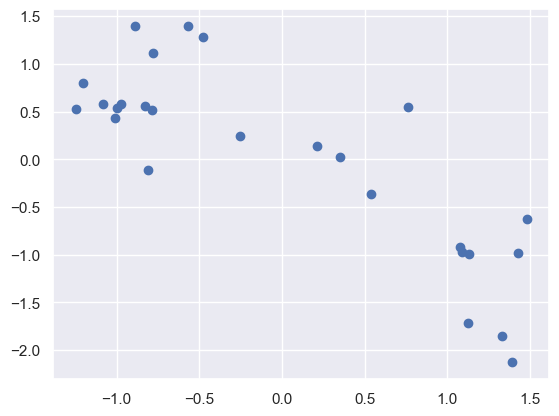

In [84]:
plt.scatter(df['GDP'], df['Fossil_Fuels'])

In [15]:
starting_df = pd.read_csv('GDP_Energy_WBdat.csv')
CO2_Upop = [starting_df['CO2_emit'].iloc[i] / starting_df['Urban_pop'].iloc[i] for i in range(0, len(starting_df))]
starting_df['CO2_Upop'] = CO2_Upop
starting_df.head()

,country,date,GDP,Fossil_Fuels,CO2_emit,Urban_pop,CO2_Upop
0,Austria,1990,21680.989623,79.132345,58275.7,4833974.0,0.012055
1,Austria,1991,22410.911767,79.127007,62423.2,4861464.0,0.012840
2,Austria,1992,24880.164118,77.237211,57668.0,4893935.0,0.011784
3,Austria,1993,24081.527793,77.011142,57804.0,4912877.0,0.011766
4,Austria,1994,25646.700659,77.585708,58288.2,4910076.0,0.011871


In [16]:
be_df = starting_df[starting_df['country'] == 'Belgium']
be_df.head()

,country,date,GDP,Fossil_Fuels,CO2_emit,Urban_pop,CO2_Upop
26,Belgium,1990,20600.375279,75.815870,109312.6,9606261.0,0.011379
27,Belgium,1991,21041.660652,76.397007,113960.1,9650427.0,0.011809
28,Belgium,1992,23372.619171,75.932201,112329.3,9697796.0,0.011583
29,Belgium,1993,22283.936021,75.935015,110108.3,9743821.0,0.011300
30,Belgium,1994,24208.554793,77.649375,114901.4,9781788.0,0.011746


In [17]:
df_standardize = be_df[['GDP', 'Fossil_Fuels', 'CO2_emit', 'Urban_pop', 'CO2_Upop']]
for itm in df_standardize.columns:
    df_standardize[itm] = (df_standardize[itm] - df_standardize[itm].mean()) / df_standardize[itm].std()

country_date_df = pd.DataFrame({'country': be_df['country'], 'date': be_df['date']})

df = pd.concat([country_date_df, df_standardize], axis = 1)
# df

/var/folders/zp/qttylnvd4ns78y392c75bxcw0000gn/T/ipykernel_47250/1372722825.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_standardize[itm] = (df_standardize[itm] - df_standardize[itm].mean()) / df_standardize[itm].std()


## Part 2.2: Cross Validate, Predict, MSE, and $R^2$ (10 points)

Create arrays `X` and `y` which contain your chosen $x$ and $y$ features (these will both be 1-d arrays for this problem).

Use the `train_test_split` function (with the **the `random_state=42` option**) which I've imported for you below to create a single-fold (70-30 split) cross validation set (i.e. `Xtrain`, `Xtest`, `ytrain`, `ytest`) using the data you cleaned in Part 2.1. In other words, for example, the `Xtrain` set should contain a random subset of about 70\% of the `X` values.

Using your functions from Part 1, apply the `line_of_best_fit` function to training data and use the `linreg_predict` function with the test data (and the output from the first function). Print out the resulting cross validated $MSE$ and $R^2$ values and **then**, in a markdown cell, interpret $R^2$ and discuss (based on that alone) if you think it is reasonable to predict your $y$ value with your $x$ value.

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
# use fossil fuels to predict co2 emit

crossval = train_test_split(df['GDP'], df['Fossil_Fuels'], test_size = 0.3, random_state = 42)
Xtrain, Xtest, ytrain, ytest = crossval

In [21]:
best_fit = line_of_best_fit(Xtrain, ytrain)
# best_fit

In [22]:
y_pred = linreg_predict(Xtest, ytest, best_fit)
# y_pred

In [23]:
mse = np.mean((ytest - y_pred['ypreds']) ** 2)
mse

0.13936830675753104

In [24]:
print(r2_score(ytest, y_pred['ypreds']))

0.6422254963669187


With an $r^2$ value of about 0.642, I think it is fairly reasonable to be able to predict Fossil Fuel energy consumption using GDP. It correctly predicts 64% of the variance of fossil fuel usage explained by GDP, and while there could be improvements, its accuracy rate is over 50%.

## Part 2.3: Plot and Interpret the Full Line (10 points)

Now, fit the regression model to the full data set, then use the `show_fit()` function below to plot it and recover the final best fit line for the model. **Note** that your `line_of_best_fit` function is the only one you need here, and that you will have to remember which value in the output vector is the slope and which is the intercept.

**In a markdown cell**, interpret both the slope and intercept in the context of the problem, explaining what they mean (as best as you can). **Recall** you standardized both the features earlier, which will impact your interpretation; think critically about that.

In [27]:
sns.set()

def get_mse(y_true, y_pred):
    """ gets the MSE

    Args:
        y_true (array): the true y values
        y_pred (array): the predicted y values

    Returns:
        the mean squared error

    """
    
    return np.mean((y_true - y_pred) ** 2)

def show_fit(X, y, slope, intercept):
    """ plots a simple linear regression line through x y points and prints the slope, intercept, and MSE

    Args:
        X (array): the design matrix
        y (array): the response variable
        slope (float): the slope
        intercept (float): the intercept

    Returns:
        A plot (I'm getting lazy with these...)
    """
    
    plt.figure()
    
    # in case this wasn't done before, transform the input data into numpy arrays and flatten them
    x = np.array(X).ravel()
    y = np.array(y).ravel()
    
    # plot the actual data
    plt.scatter(x, y, label='data')
    
    # compute linear predictions 
    # x is a numpy array so each element gets multiplied by slope and intercept is added
    y_pred = slope * x + intercept
    
    # plot the linear fit
    plt.plot(x, y_pred, color='black',
             ls=':',
             label='linear fit')
    
    plt.legend()
    
    plt.xlabel('x')
    plt.ylabel('y')
    
    # print the mean squared error
    y_pred = slope * x + intercept
    mse = get_mse(y_true=y, y_pred=y_pred)
    plt.suptitle(f'y_hat = {slope:.3f} * x + {intercept:.3f}, MSE = {mse:.3f}')

In [28]:
best_fit = line_of_best_fit(df['GDP'], df['Fossil_Fuels'])
best_fit

array([-3.89817929e-15, -8.29917098e-01])

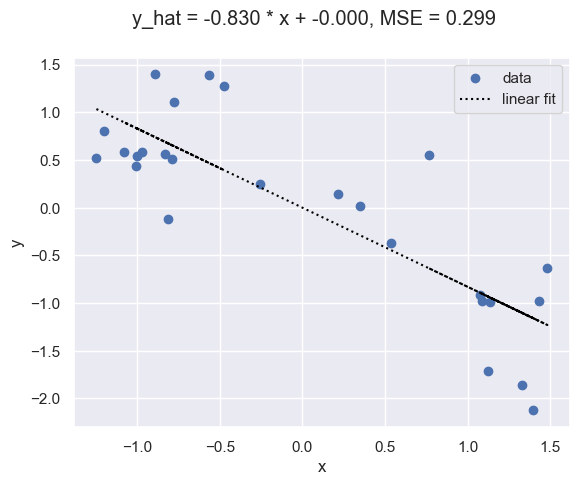

In [29]:
show_fit(df['GDP'], df['Fossil_Fuels'], best_fit[1], best_fit[0])

#### Interpretation

The slope of this problem is about -0.830, and the y-intercept is 0. In the context of the problem, this means that when GDP is 0, fossil fuel usage is at -0.830. Both of these seem rather unrealistic to me; it doesn't seem theoretically possible for GDP to be at 0 in today's society, and I don't see how fossil fuel usage can be in the negative numbers. Standardization, which makes the comparison features "unit invariant," allows for an easier comparison between GDP and Fossil Fuels. Normally, GDP and Fossil Fuels are not measured in the same units, so standardization gives us a way to accurately compare them.

## Part 2.4: Check Assumptions and Make Recommendations (10 points)

Use two plots to check to see if the residuals meet the assumptions for performing a *simple* linear regression:
1. linearity and homoscedasticity
2. no autocorrelation

**Note** that you will want to use your `linreg_predict` function, using the **full data set** as your `Xnew` and `ynew` values, to get the residuals for the purposes of this question.

Then, **in a markdown cell**, write 3-4 sentences about whether the model meets the assumptions, what that tells you about the usefulness of the model, and recommendations for next steps (if any).

In [32]:
full_preds = linreg_predict(df['GDP'], df['Fossil_Fuels'], best_fit)
# full_preds

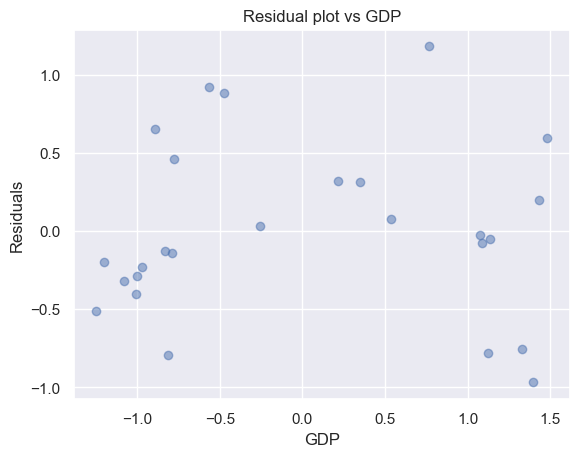

In [33]:
# linearity and homoscedasticity plot
plt.scatter(df['GDP'], full_preds['resids'], alpha=0.5)
plt.xlabel('GDP')
plt.ylabel('Residuals')
plt.title('Residual plot vs GDP')
plt.show()

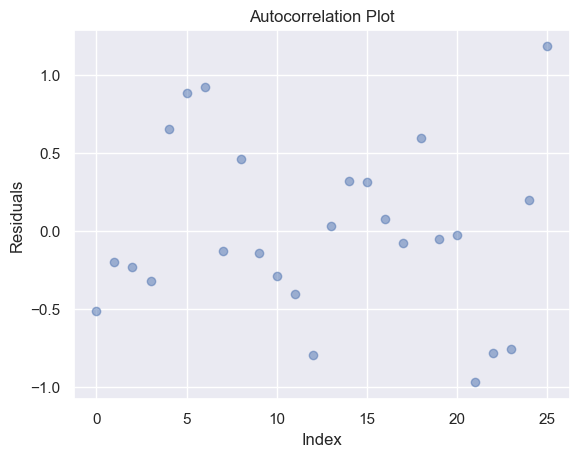

In [35]:
plt.scatter(range(len(df['GDP'])), full_preds['resids'], alpha=0.5)
plt.title('Autocorrelation Plot')
plt.xlabel('Index')
plt.ylabel('Residuals')
plt.show()

#### Interpretation
In the residual plot, there is no clear visual pattern in in the data points, which means that the linearity assumption holds true. In terms of homoscedascity, since the residuals are generally equally spread out around the plot, it is safe to say that the homoscedascity assumption holds as well.

For the autocorrelation plot, since the points are randomly scattered throughout the plot, there does not seem to be autocorrelation in the model.

Since the model meets all of the assumptions, it can be presumed that the model is reasonably useful. To test this further, one could test it with more new data and see how it performs.

# Part 3: More Complex Regression 

## Part 3.1: Predicting GDP (15 points)

Suppose a Belgian policy maker comes to you now and asks you to use this data to build a model to predict `GDP` **specifically**. To build a linear regression model for GDP using **more than 1 predictor** (i.e. include at least one additional $x$ feature(s) as linear terms for your model):

1. Fit your model to a training set and the evaluate on a testing set; report the training $MSE$, $R^2$. Then, fit the full data set and interpret the intercept and slopes (you will have multiple slopes, since you will have more than 1 predictor).
2. Check the assumptions of linearity, homoscedasticity, and no autocorrelation using the residuals of the full data set.
   - **Note** To check homoscedasticity and linearity, you should plot *each* of the $x$ features you choose against the residuals.
4. Finally, decide (based on what you've done) if the model you built seems like a useful model that you would be willing to show to the Belgian policy maker.

In [38]:
X_vals = df[['Urban_pop', 'CO2_Upop']].values
crossval2 = train_test_split(X_vals, df['GDP'], test_size = 0.3, random_state = 42)
Xtrain2, Xtest2, ytrain2, ytest2 = crossval2

best_fit_train = line_of_best_fit(Xtrain2, ytrain2)
ypred2 = linreg_predict(Xtest2, ytest2, best_fit_train)

print(f'MSE: {ypred2['mse']}')
print(f'R2: {ypred2['r2']}')

MSE: 0.09641010212637335
R2: 0.8769158480849943


In [39]:
best_fit_full = line_of_best_fit(X_vals, df['GDP'])
best_fit_full

array([ 4.18943118e-17,  7.54382464e-01, -1.65140446e-01])

#### Interpretation

The model has a slope of around 0.7543 when comparing Urban_pop and GDP and a slope of around -0.165 when comparing CO2_Upop with GDP. This means that GDP increases when urban population increases and decreases when CO2 emissions increase. So, a higher population could indicate a higher GDP and an increase of CO2 emissions could indicate a lower GDP.

In [41]:
resids_full = linreg_predict(X_vals, df['GDP'], best_fit_full)
# resids_full

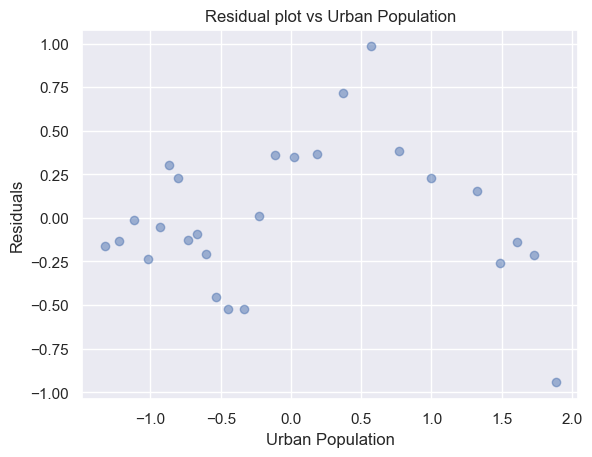

In [42]:
# lin/hom urbanpop
plt.scatter(df['Urban_pop'], resids_full['resids'], alpha=0.5)
plt.xlabel('Urban Population')
plt.ylabel('Residuals')
plt.title('Residual plot vs Urban Population')
plt.show()

In this plot, there is a clear curve with the data points, which means linearity is violated. In terms of homoscedascity, the points are generally spread out evenly among the plot, but some places (like the left part of the graph) has points more concentrated. So, there is some heteroscedascity, but it is not perfect.

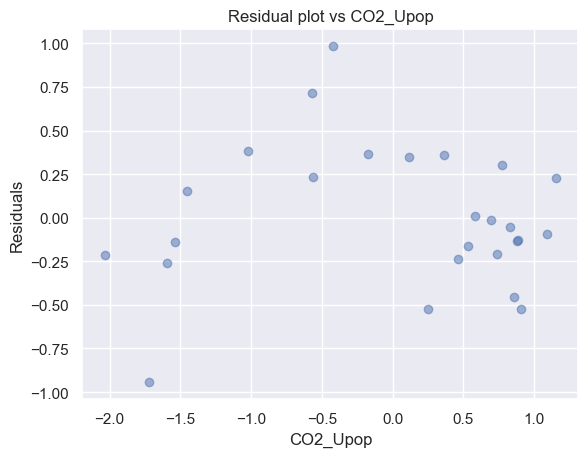

In [44]:
# lin/hom co2_upop
plt.scatter(df['CO2_Upop'], resids_full['resids'], alpha=0.5)
plt.xlabel('CO2_Upop')
plt.ylabel('Residuals')
plt.title('Residual plot vs CO2_Upop')
plt.show()

Similarly to the plot above, there is a clear curve with the data points, which means linearity is violated. For homoscedascity, the points are generally spread out evenly among the plot, but it seems that most of the points are concentrated on the right side of the graph. This tells me that heteroscedascity is violated.

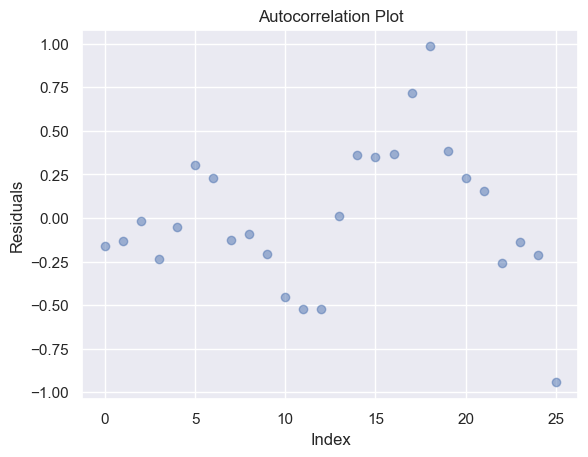

In [46]:
# autocorrelation urbanpop
plt.scatter(range(len(df['Urban_pop'])), resids_full['resids'], alpha=0.5)
plt.title('Autocorrelation Plot')
plt.xlabel('Index')
plt.ylabel('Residuals')
plt.show()

While the points are somewhat randomly scattered throughout the plot, there seems to be a slight linear trend with most of the points around the x-axis. This means that autocorrelation is violated.

Judging by the low MSE and high R^2 value alone, I would be proud to show this to the Belgian policy maker. However, seeing that linearity, homoscedascity, and autocorrelation are violated, this model definitely needs some more work. At this point, I do not think I would like to show it to the policy maker until I knew the assumptions were not violated.

## Part 3.2: The Last Assumption (5 points)

The Belgian policy maker, when assigning you the previous task, had suggested to use all the other features to help predict `GDP`. Whether you did or not, do you think there may be reason to believe such a model would be at risk of multicollinearity issues? Explain (to the policy maker) why that may or may not be in a few sentences.

Since the other features of the model are GDP, Fossil Fuels, Co2 emissions, and urban population I believe the model would be at risk of multicollinearity. Multicollinearity is when features that are being used to predict another feature are correlated with each other, so the model does not know which feature (if any) is actually affecting changes in the y value. In this case, it is highly likely that fossil fuels and co2 emissions are correlated with each other, which would cause multicollinearity 

## Part 3.3: Extra Credit (5 points)

We want to compare a simple linear model (if you haven't already) predicting GDP with Fossil Fuels, and a **quadratic** model with Fossil Fuels (i.e. your $X$ design matrix will include a column with Fossil Fuels ($x$ values) and Fossil Fuels squared ($x^2$)). 

1. Fit both models with the full data set and compare their $MSE$ and $R^2$ values; which model (based on these values) would you choose?
2. Check the assumptions of homoscedasticity and no autocorrelation using residual plots for both models (since there is only one $x$ feature for both models, you only need two plots for each).
3. Make a declaration about which model is "better", and if you think the "better" model is actually good, or may need more work.